In [1]:
import sys
print("Versión de Python:", sys.version)

Versión de Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [4]:
# Verificar instalación de pandas, matplotlib y scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("¡Librerías cargadas correctamente!")

¡Librerías cargadas correctamente!


In [10]:
df = pd.read_csv(r"C:\Users\DANI\Downloads\Data set car\CAR DETAILS FROM CAR DEKHO.csv")

In [12]:
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
df2 = pd.read_csv(r"C:\Users\DANI\Downloads\Data set car\car data.csv")

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [16]:
# Ver estadísticas básicas del dataset
df.describe()


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [18]:
# sirve para verificar si hay valores nulos
print(df.isnull().sum())


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


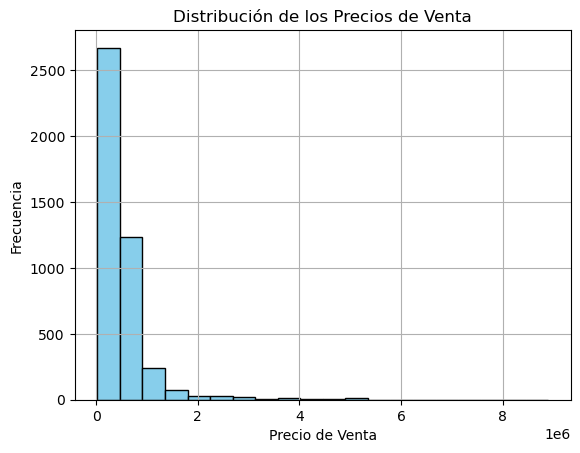

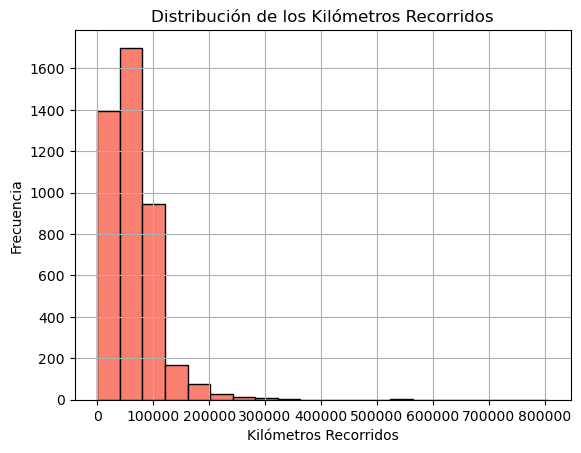

In [20]:
# Histograma para ver la distribución de los precios de venta
df['selling_price'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de los Precios de Venta')
plt.xlabel('Precio de Venta')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para ver la distribución de los kilómetros recorridos
df['km_driven'].hist(bins=20, color='salmon', edgecolor='black')
plt.title('Distribución de los Kilómetros Recorridos')
plt.xlabel('Kilómetros Recorridos')
plt.ylabel('Frecuencia')
plt.show()


In [24]:
import seaborn as sns


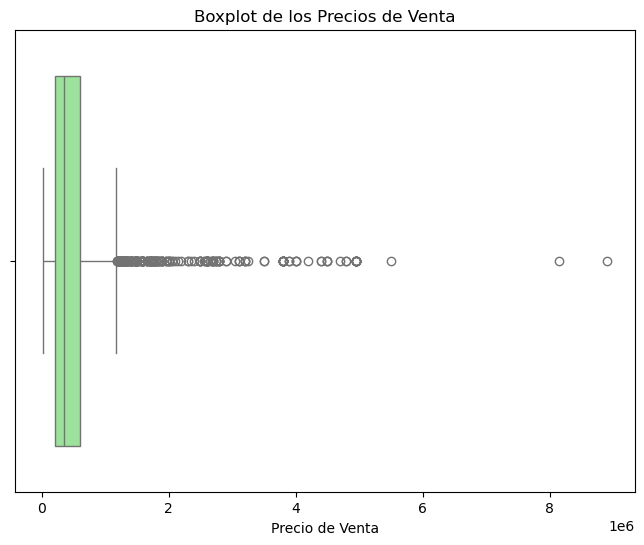

In [26]:
# Boxplot para los precios de venta
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['selling_price'], color='lightgreen')
plt.title('Boxplot de los Precios de Venta')
plt.xlabel('Precio de Venta')
plt.show()


In [28]:
df['selling_price'].describe()


count    4.340000e+03
mean     5.041273e+05
std      5.785487e+05
min      2.000000e+04
25%      2.087498e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

In [28]:
df['selling_price'].describe()


count    4.340000e+03
mean     5.041273e+05
std      5.785487e+05
min      2.000000e+04
25%      2.087498e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

In [34]:
# Definimos los cuartiles manualmente
Q1 = 208749.75
Q3 = 600000

# Calculamos el IQR
IQR = Q3 - Q1

# Calculamos el límite superior para detectar outliers
limite_superior = Q3 + 1.5 * IQR

# Filtramos el DataFrame para quedarnos solo con los precios dentro del rango
df = df[df['selling_price'] <= limite_superior]


In [36]:
print("Cantidad de registros después de limpiar:", len(df))


Cantidad de registros después de limpiar: 4069


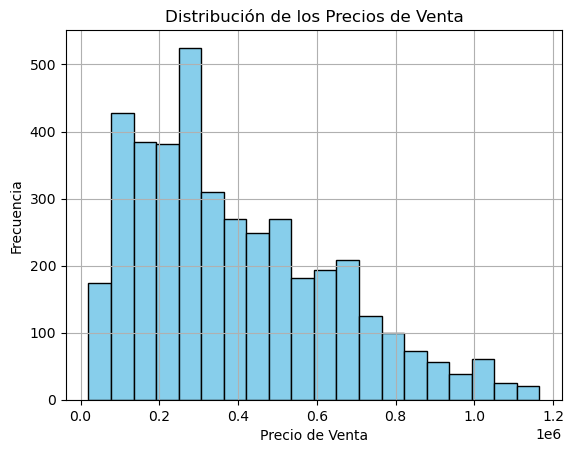

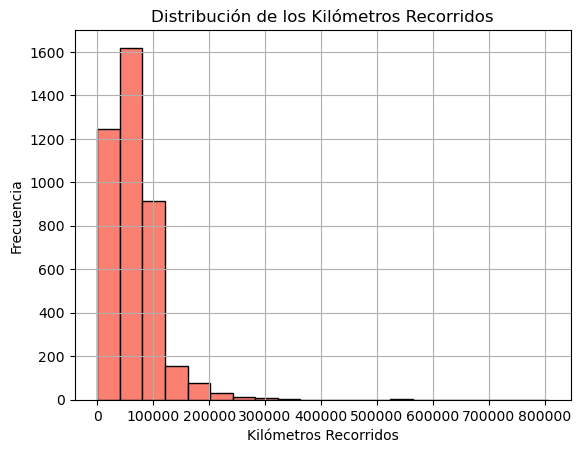

In [38]:
# Histograma para ver la distribución de los precios de venta
df['selling_price'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de los Precios de Venta')
plt.xlabel('Precio de Venta')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para ver la distribución de los kilómetros recorridos
df['km_driven'].hist(bins=20, color='salmon', edgecolor='black')
plt.title('Distribución de los Kilómetros Recorridos')
plt.xlabel('Kilómetros Recorridos')
plt.ylabel('Frecuencia')
plt.show()


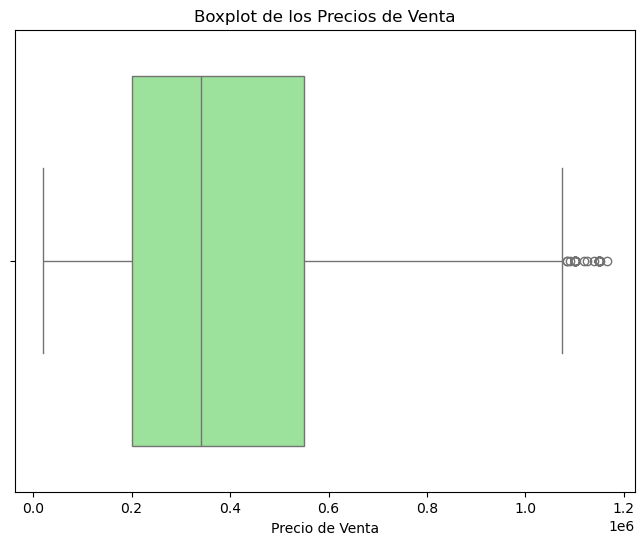

In [40]:
# Boxplot para los precios de venta
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['selling_price'], color='lightgreen')
plt.title('Boxplot de los Precios de Venta')
plt.xlabel('Precio de Venta')
plt.show()


In [43]:
# Crear la columna de antigüedad
df['antigüedad'] = 2025 - df['year']


In [45]:
# Codificar variables categóricas de manera simple
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)


In [49]:
# Excluir la columna 'name' (y cualquier otra columna no numérica)
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcular la correlación entre las variables numéricas
correlation_matrix = df_numeric.corr()

# Mostrar la correlación con 'selling_price'
print(correlation_matrix['selling_price'])


year             0.625484
selling_price    1.000000
km_driven       -0.227147
antigüedad      -0.625484
Name: selling_price, dtype: float64


In [51]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en características (X) y la variable objetivo (y)
X = df[['year', 'km_driven', 'antigüedad']]  # Características relevantes
y = df['selling_price']  # La variable objetivo

# Dividir en Train y Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ver las dimensiones del conjunto de datos
print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")


Conjunto de entrenamiento: (3255, 3)
Conjunto de prueba: (814, 3)


In [53]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Mostrar los coeficientes del modelo
print("Coeficientes del modelo:", model.coef_)
print("Intercepto:", model.intercept_)


Coeficientes del modelo: [ 1.86485803e+04  1.75024699e-01 -1.86485803e+04]
Intercepto: -36929808.30379794


In [55]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el rendimiento
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Mostrar las métricas
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2: {r2}")


Mean Squared Error (MSE): 34242314257.92416
Root Mean Squared Error (RMSE): 185046.78937480695
R^2: 0.408979526425963


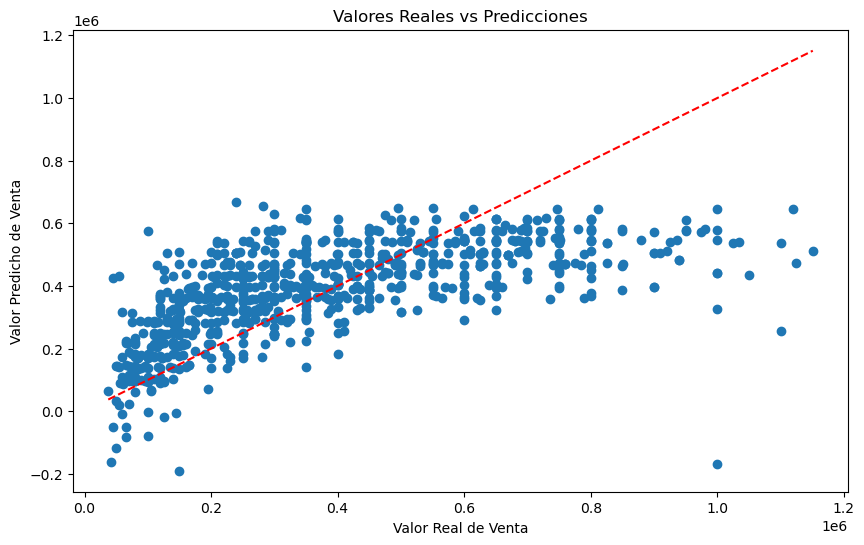

In [57]:
import matplotlib.pyplot as plt

# Graficar los valores reales vs las predicciones
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Línea de identidad
plt.xlabel('Valor Real de Venta')
plt.ylabel('Valor Predicho de Venta')
plt.title('Valores Reales vs Predicciones')
plt.show()


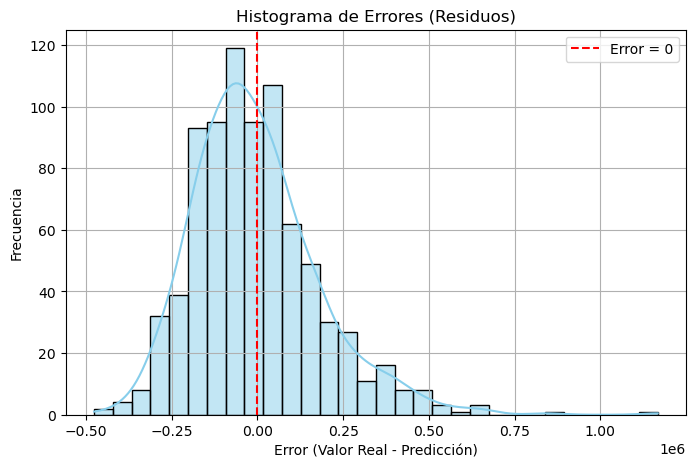

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos los errores (residuos)
errores = y_test - y_pred

# Creamos el histograma
plt.figure(figsize=(8,5))
sns.histplot(errores, bins=30, kde=True, color='skyblue')
plt.title("Histograma de Errores (Residuos)")
plt.xlabel("Error (Valor Real - Predicción)")
plt.ylabel("Frecuencia")
plt.axvline(x=0, color='red', linestyle='--', label='Error = 0')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
import os
os.getcwd()


'C:\\Users\\DANI\\Downloads\\Data set car'